# Phase 5: Prediksi Spasial & Pemetaan (Spatial Prediction & Mapping)

Notebook ini berfokus pada pembuatan grid spasial 1km x 1km wilayah Jakarta, memprediksi nilai PM2.5 menggunakan model RFR yang telah terlatih, dan memvisualisasikan hasilnya dalam bentuk peta kontur atau heatmap polusi.

## Muat Model

In [26]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import Rbf
import joblib

# Set style visualisasi premium
sns.set_theme(style="ticks")
plt.rcParams['figure.figsize'] = [20, 10] # Diperlebar untuk side-by-side
plt.rcParams['figure.dpi'] = 150

# Memuat kedua model (.pkl)
rfr_path = os.path.join('data', 'pm25_rfr_model.pkl')
etr_path = os.path.join('data', 'pm25_etr_model.pkl')

if not os.path.exists(rfr_path) or not os.path.exists(etr_path):
    raise FileNotFoundError("Pastikan file pm25_rfr_model.pkl dan pm25_etr_model.pkl sudah tersimpan di direktori data/")

model_rfr = joblib.load(rfr_path)
model_etr = joblib.load(etr_path)

print("✓ Model Random Forest (RFR) berhasil dimuat.")
print("✓ Model Extra Trees (ETR) berhasil dimuat.")

✓ Model Random Forest (RFR) berhasil dimuat.
✓ Model Extra Trees (ETR) berhasil dimuat.


## Load Data & Select Sample Timestep

In [27]:
# 1. Load dataset model ready
data_path = os.path.join('data', 'model_ready_data.csv')
df = pd.read_csv(data_path)
df['waktu'] = pd.to_datetime(df['waktu'])

# 2. Buat fitur lag cuaca 1 jam yang lalu (sama dengan Notebook 04)
df = df.sort_values(by=['stasiun', 'waktu']).reset_index(drop=True)
df['v_wind_lag1'] = df.groupby('stasiun')['v_wind'].shift(1)
df['u_wind_lag1'] = df.groupby('stasiun')['u_wind'].shift(1)
df['temp_lag1'] = df.groupby('stasiun')['temperature_2m'].shift(1)
df['rh_lag1'] = df.groupby('stasiun')['relative_humidity_2m'].shift(1)

# Hapus baris NaN hasil shifting
df = df.dropna(subset=['v_wind_lag1', 'u_wind_lag1', 'temp_lag1', 'rh_lag1']).reset_index(drop=True)

# 3. Definisikan pembagian grid group CAMS (untuk validasi logis stasiun)
def get_grid_group(stasiun):
    if stasiun in ['Menteng', 'Slipi', 'Kelapa Gading Indah']:
        return 'Group_A'
    elif stasiun in ['Jagakarsa', 'Jatinegara']:
        return 'Group_B'
    return 'Unknown'
df['grid_group'] = df['stasiun'].apply(get_grid_group)

# 4. Tampilkan contoh jam sampel historis
df_pivot = df.pivot(index='waktu', columns='stasiun', values='PM2.5')
print("Menampilkan beberapa jam terakhir dengan PM2.5 sebagai acuan pemilihan waktu sampel:")
print(df_pivot.tail(5))

# Pilih waktu sampel Rabu, 18 Juni 2025
sample_time = pd.Timestamp('2025-06-18 12:00:00')
print(f"\nWaktu sampel terpilih untuk pemetaan: {sample_time}")

Menampilkan beberapa jam terakhir dengan PM2.5 sebagai acuan pemilihan waktu sampel:
stasiun              Jagakarsa  Jatinegara  Kelapa Gading Indah  Menteng  \
waktu                                                                      
2026-01-01 19:00:00       58.3        58.3                 32.0     32.0   
2026-01-01 20:00:00       55.8        55.8                 30.4     30.4   
2026-01-01 21:00:00       51.6        51.6                 28.8     28.8   
2026-01-01 22:00:00       49.2        49.2                 27.8     27.8   
2026-01-01 23:00:00       46.6        46.6                 28.8     28.8   

stasiun              Slipi  
waktu                       
2026-01-01 19:00:00   32.0  
2026-01-01 20:00:00   30.4  
2026-01-01 21:00:00   28.8  
2026-01-01 22:00:00   27.8  
2026-01-01 23:00:00   28.8  

Waktu sampel terpilih untuk pemetaan: 2025-06-18 12:00:00


## Create Jakarta 1km x 1km Grid

In [28]:
# 1. Definisikan batas wilayah administratif Jakarta (Bounding Box)
# Latitude (Lintang): -6.37 s.d. -6.08 (Selatan ke Utara)
# Longitude (Bujur): 106.68 s.d. 106.97 (Barat ke Timur)
lat_min, lat_max = -6.37, -6.08
lon_min, lon_max = 106.68, 106.97

# Definisikan resolusi grid 1km (sekitar 0.009 derajat)
grid_resolution = 0.009

grid_lat = np.arange(lat_min, lat_max, grid_resolution)
grid_lon = np.arange(lon_min, lon_max, grid_resolution)

# 2. Buat matriks 2D meshgrid
grid_x, grid_y = np.meshgrid(grid_lon, grid_lat)
total_pixels = grid_x.size

print(f"Grid spasial 1km x 1km Jakarta berhasil dibuat:")
print(f"Dimensi grid: {grid_x.shape[0]} baris x {grid_x.shape[1]} kolom")
print(f"Total piksel prediksi: {total_pixels}")

Grid spasial 1km x 1km Jakarta berhasil dibuat:
Dimensi grid: 33 baris x 33 kolom
Total piksel prediksi: 1089


## Spatial Interpolation of Weather Features

In [29]:
# 1. Ambil data stasiun pada jam sampel terpilih
df_sample = df[df['waktu'] == sample_time].copy()

# Koordinat stasiun asli
station_coords = {
    'Slipi': {'lat': -6.1950, 'lon': 106.8025},
    'Menteng': {'lat': -6.1994, 'lon': 106.8392},
    'Jagakarsa': {'lat': -6.3341, 'lon': 106.8214},
    'Jatinegara': {'lat': -6.2322, 'lon': 106.8811},
    'Kelapa Gading Indah': {'lat': -6.1673, 'lon': 106.9052}
}

df_sample['lat'] = df_sample['stasiun'].map(lambda s: station_coords[s]['lat'])
df_sample['lon'] = df_sample['stasiun'].map(lambda s: station_coords[s]['lon'])

points_lat = df_sample['lat'].values
points_lon = df_sample['lon'].values

# 2. Interpolasikan seluruh variabel cuaca & lag cuaca ke grid 1km x 1km
interpolated_features = {}

features_to_interpolate = [
    'temperature_2m', 'apparent_temperature', 'relative_humidity_2m',
    'dew_point_2m', 'precipitation', 'rain', 'surface_pressure',
    'cloud_cover_total', 'u_wind', 'v_wind',
    'v_wind_lag1', 'u_wind_lag1', 'temp_lag1', 'rh_lag1', 'AOD'
]

print(f"Menginterpolasi {len(features_to_interpolate)} fitur ke grid...")

for feat in features_to_interpolate:
    values = df_sample[feat].values

    # Tangani AOD jika bernilai sentinel -999.0 di semua stasiun (kondisi mendung/malam)
    if feat == 'AOD' and np.all(values == -999.0):
        interpolated_features[feat] = np.full(grid_x.shape, -999.0)
    else:
        # Gunakan Rbf Interpolation dengan kernel linear untuk gradien yang halus
        rbf = Rbf(points_lon, points_lat, values, function='linear')
        grid_values = rbf(grid_x, grid_y)
        interpolated_features[feat] = grid_values

print("✓ Interpolasi spasial seluruh fitur selesai!")

Menginterpolasi 15 fitur ke grid...
✓ Interpolasi spasial seluruh fitur selesai!


## Prediksi Spasial menggunakan Kedua Model

In [30]:
# =================================================================
# CELL 6: PREDIKSI PM2.5 SPASIAL (DENGAN KOORDINAT GRID)
# =================================================================

# 1. Flatten meshgrid koordinat untuk DataFrame prediktor X_grid
grid_df = pd.DataFrame()
grid_lon_flat = grid_x.flatten()
grid_lat_flat = grid_y.flatten()

# --- INPUT KOORDINAT GRID ASLI ---
grid_df['latitude'] = grid_lat_flat
grid_df['longitude'] = grid_lon_flat
# ---------------------------------

# Pindahkan seluruh fitur cuaca hasil interpolasi ke dataframe datar
for feat in features_to_interpolate:
    grid_df[feat] = interpolated_features[feat].flatten()

# 2. Tambahkan fitur temporal konstan dari jam sampel
sample_row = df_sample.iloc[0]
grid_df['jam'] = sample_row['jam']
grid_df['bulan'] = sample_row['bulan']
grid_df['hari_dalam_minggu'] = sample_row['hari_dalam_minggu']
grid_df['is_weekend'] = sample_row['is_weekend']

# 3. Susun urutan kolom lengkap DENGAN koordinat (latitude & longitude)
features_with_coords_lags = [
    'latitude', 'longitude',                             # Pastikan koordinat ada di depan
    'temperature_2m', 'apparent_temperature', 'relative_humidity_2m',
    'dew_point_2m', 'precipitation', 'rain', 'surface_pressure',
    'cloud_cover_total', 'u_wind', 'v_wind', 'jam', 'bulan',
    'hari_dalam_minggu', 'is_weekend', 'AOD',
    'v_wind_lag1', 'u_wind_lag1', 'temp_lag1', 'rh_lag1'
]
X_grid = grid_df[features_with_coords_lags]

# 4. Prediksi PM2.5 menggunakan kedua model teroptimasi
pred_rfr = model_rfr.predict(X_grid)
pred_etr = model_etr.predict(X_grid)

# Reshape hasil prediksi kembali ke bentuk meshgrid 2D
grid_pred_rfr_2d = pred_rfr.reshape(grid_x.shape)
grid_pred_etr_2d = pred_etr.reshape(grid_x.shape)

print("Prediksi PM2.5 Spasial (Dengan Koordinat Grid) selesai dilakukan:")
print(f"[RFR] Rentang: {pred_rfr.min():.2f} - {pred_rfr.max():.2f} | Rata-rata: {pred_rfr.mean():.2f} µg/m³")
print(f"[ETR] Rentang: {pred_etr.min():.2f} - {pred_etr.max():.2f} | Rata-rata: {pred_etr.mean():.2f} µg/m³")

Prediksi PM2.5 Spasial (Dengan Koordinat Grid) selesai dilakukan:
[RFR] Rentang: 61.29 - 107.04 | Rata-rata: 86.69 µg/m³
[ETR] Rentang: 55.14 - 110.32 | Rata-rata: 84.43 µg/m³


## Visualisasi Perbandingan Peta Spasial RFR vs ETR

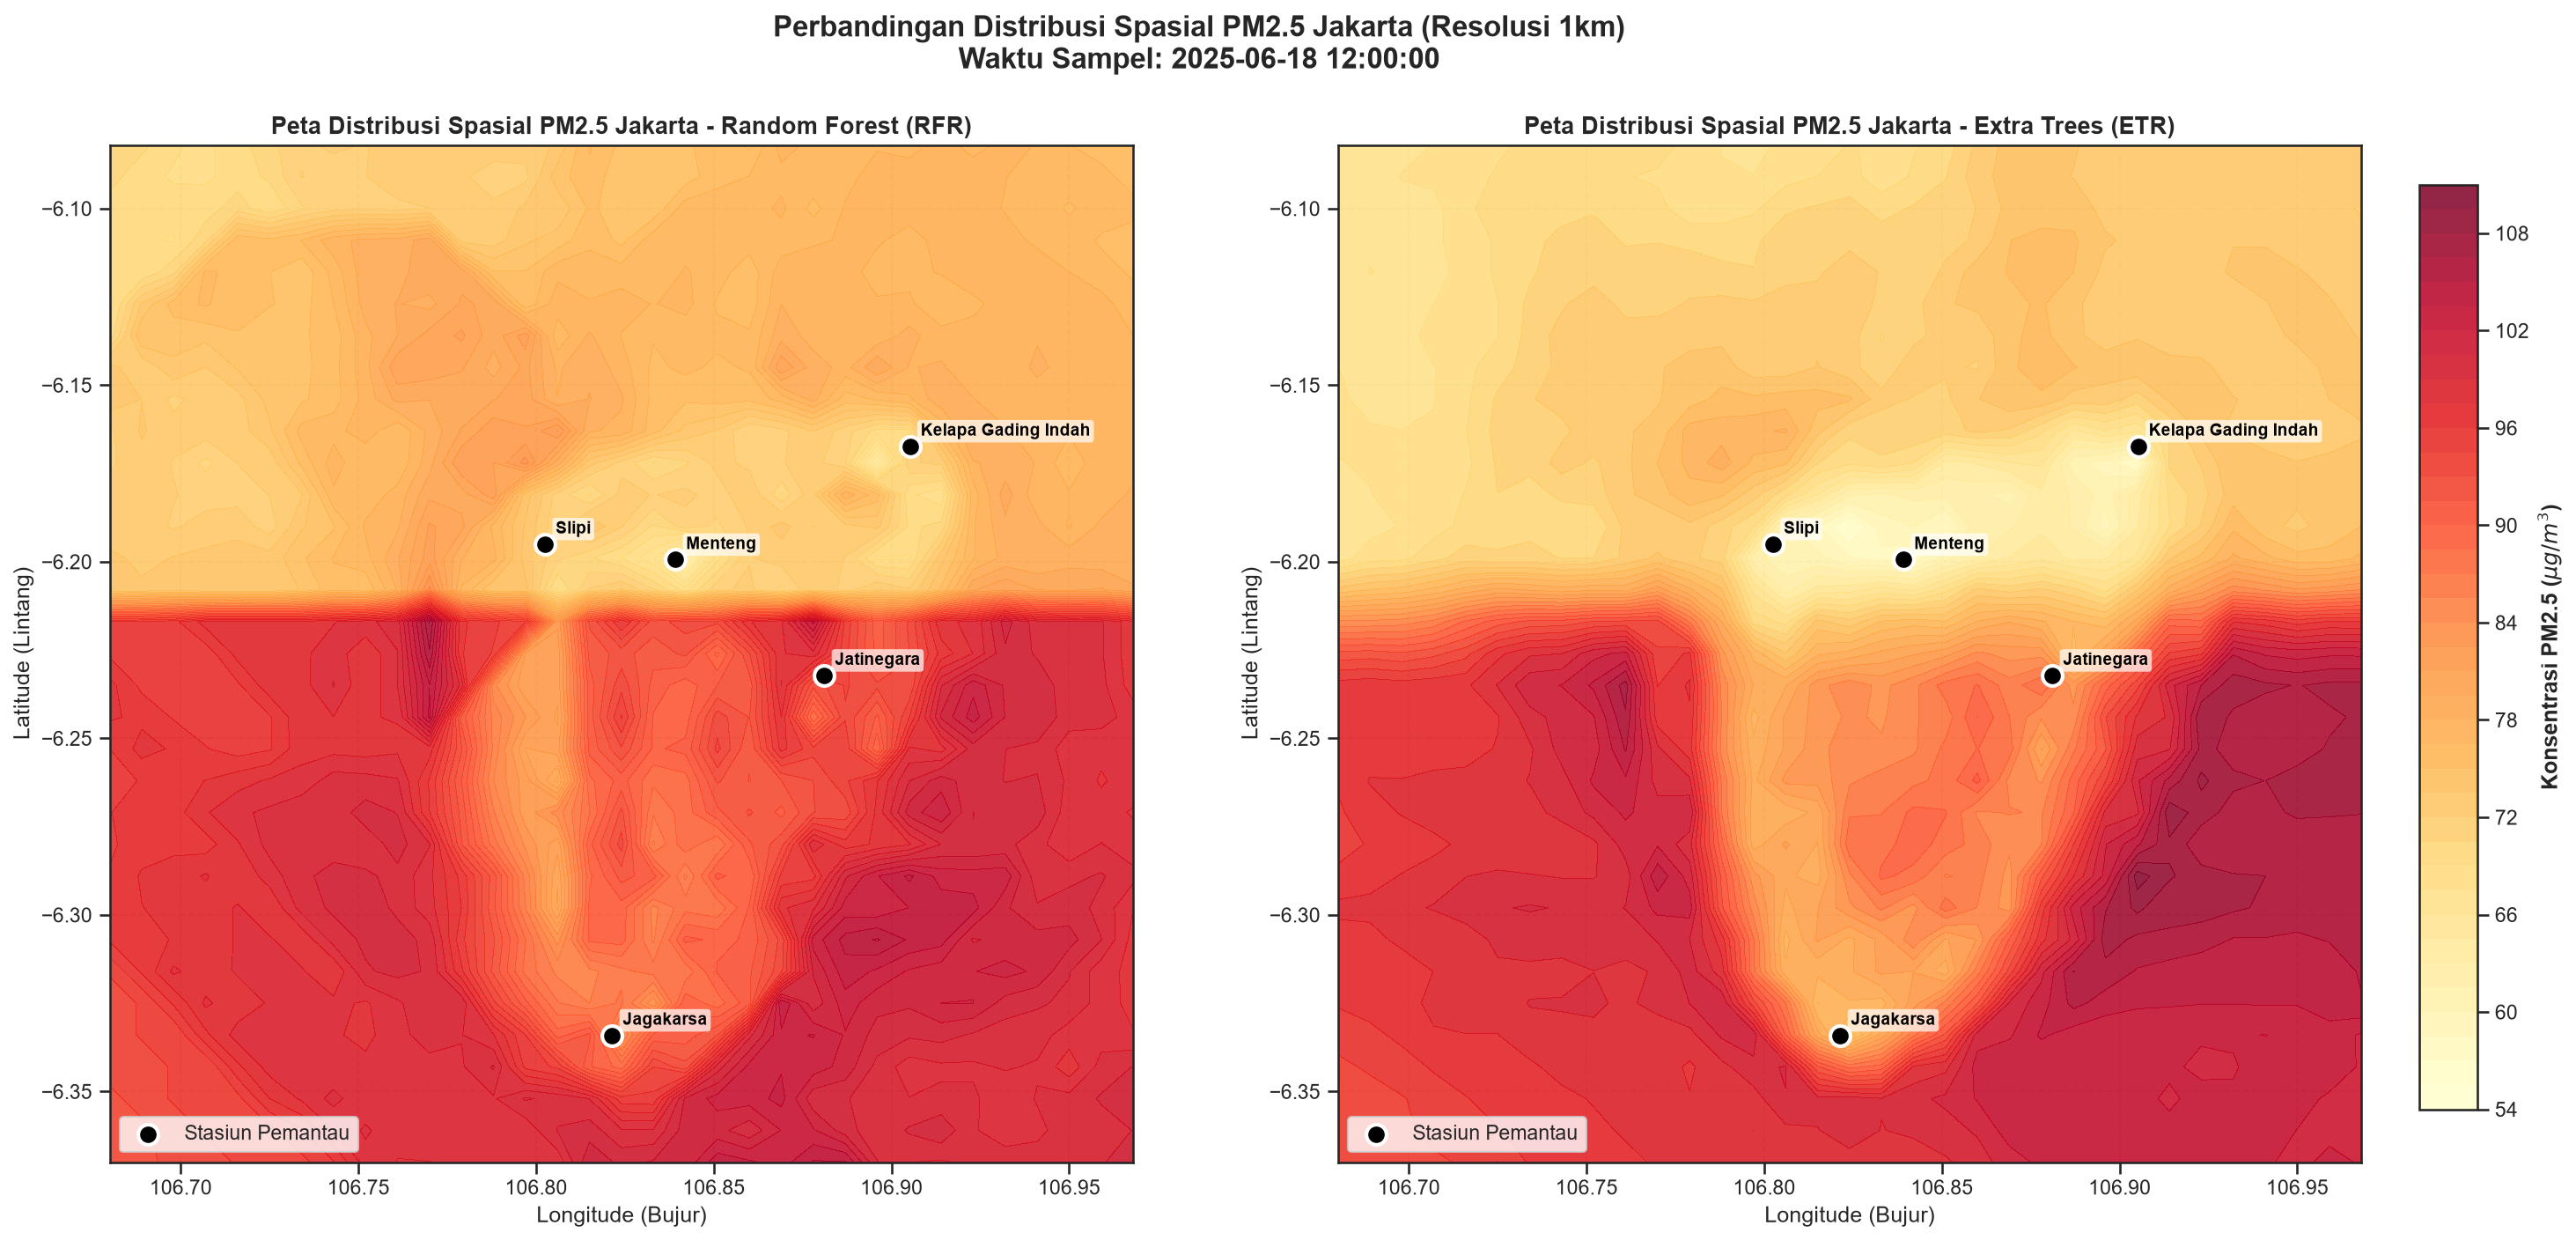

✓ Peta perbandingan spasial PM2.5 berhasil disimpan di: results\images\jakarta_pm25_map_comparison.png


In [31]:
# 1. Buat subplot 1 baris, 2 kolom untuk perbandingan berdampingan
fig, axes = plt.subplots(1, 2, figsize=(22, 10))

# Rentang skala warna (Colorbar limits) disamakan agar perbandingan adil
vmin_val = min(pred_rfr.min(), pred_etr.min())
vmax_val = max(pred_rfr.max(), pred_etr.max())

# -----------------
# SUBPLOT 1: RANDOM FOREST REGRESSOR
# -----------------
contour_rfr = axes[0].contourf(grid_x, grid_y, grid_pred_rfr_2d, levels=50, cmap='YlOrRd', vmin=vmin_val, vmax=vmax_val, alpha=0.85)
axes[0].scatter(points_lon, points_lat, color='black', edgecolor='white', s=120, linewidth=2, label='Stasiun Pemantau')

# Tambahkan label stasiun
for idx, row in df_sample.iterrows():
    axes[0].text(
        row['lon'] + 0.003, row['lat'] + 0.003, row['stasiun'],
        fontsize=9, fontweight='bold', color='black',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.2')
    )

axes[0].set_title('Peta Distribusi Spasial PM2.5 Jakarta - Random Forest (RFR)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Longitude (Bujur)')
axes[0].set_ylabel('Latitude (Lintang)')
axes[0].legend(loc='lower left')
axes[0].grid(True, linestyle='--', alpha=0.5)

# -----------------
# SUBPLOT 2: EXTRA TREES REGRESSOR
# -----------------
contour_etr = axes[1].contourf(grid_x, grid_y, grid_pred_etr_2d, levels=50, cmap='YlOrRd', vmin=vmin_val, vmax=vmax_val, alpha=0.85)
axes[1].scatter(points_lon, points_lat, color='black', edgecolor='white', s=120, linewidth=2, label='Stasiun Pemantau')

# Tambahkan label stasiun
for idx, row in df_sample.iterrows():
    axes[1].text(
        row['lon'] + 0.003, row['lat'] + 0.003, row['stasiun'],
        fontsize=9, fontweight='bold', color='black',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.2')
    )

axes[1].set_title('Peta Distribusi Spasial PM2.5 Jakarta - Extra Trees (ETR)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Longitude (Bujur)')
axes[1].set_ylabel('Latitude (Lintang)')
axes[1].legend(loc='lower left')
axes[1].grid(True, linestyle='--', alpha=0.5)

# 2. Tambahkan satu colorbar bersama untuk kedua peta
fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(contour_etr, cax=cbar_ax) # <-- Diubah dari cbar_ax menjadi cax
cbar.set_label(r'Konsentrasi PM2.5 ($\mu g/m^3$)', fontsize=12, fontweight='bold')

plt.suptitle(f'Perbandingan Distribusi Spasial PM2.5 Jakarta (Resolusi 1km)\nWaktu Sampel: {sample_time}', fontsize=16, fontweight='bold')

# Simpan grafik perbandingan peta
map_output_path = os.path.join('results', 'images', 'jakarta_pm25_map_comparison.png')
os.makedirs(os.path.dirname(map_output_path), exist_ok=True)
plt.savefig(map_output_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Peta perbandingan spasial PM2.5 berhasil disimpan di: {map_output_path}")

## Validasi dengan Stasiun Baru

In [34]:
# =================================================================
# CELL EKSPERIMEN: VALIDASI 24 JAM DENGAN FITUR KOORDINAT
# =================================================================
from sklearn.ensemble import ExtraTreesRegressor

# 1. Masukkan kembali fitur koordinat ke dalam prediktor
features_with_coords_lags = [
    'latitude', 'longitude',                                 # Koordinat dimasukkan kembali
    'temperature_2m', 'apparent_temperature', 'relative_humidity_2m',
    'dew_point_2m', 'precipitation', 'rain', 'surface_pressure',
    'cloud_cover_total', 'u_wind', 'v_wind', 'jam', 'bulan',
    'hari_dalam_minggu', 'is_weekend', 'AOD',
    'v_wind_lag1', 'u_wind_lag1', 'temp_lag1', 'rh_lag1'
]
target = 'PM2.5'

# 2. Latih model final menggunakan koordinat asli pada seluruh data stasiun
df_lag_train = df.sort_values(by=['stasiun', 'waktu']).reset_index(drop=True)
df_lag_train['v_wind_lag1'] = df_lag_train.groupby('stasiun')['v_wind'].shift(1)
df_lag_train['u_wind_lag1'] = df_lag_train.groupby('stasiun')['u_wind'].shift(1)
df_lag_train['temp_lag1'] = df_lag_train.groupby('stasiun')['temperature_2m'].shift(1)
df_lag_train['rh_lag1'] = df_lag_train.groupby('stasiun')['relative_humidity_2m'].shift(1)
df_lag_train = df_lag_train.dropna(subset=['v_wind_lag1', 'u_wind_lag1', 'temp_lag1', 'rh_lag1']).reset_index(drop=True)

X_train_final = df_lag_train[features_with_coords_lags]
y_train_final = df_lag_train[target]

# Gunakan Extra Trees teroptimasi
model_etr_coords = ExtraTreesRegressor(
    n_estimators=200, max_depth=None, max_features=None, min_samples_split=5, random_state=42, n_jobs=-1
)
model_etr_coords.fit(X_train_final, y_train_final)

# 3. Siapkan data uji Kembangan (Depok/Jakarta Barat) dengan koordinat aslinya
df_val_24h_coords = df_val_24h.copy()
df_val_24h_coords['latitude'] = val_lat
df_val_24h_coords['longitude'] = val_lon

X_test_val = df_val_24h_coords[features_with_coords_lags]
y_actual_val = df_val_24h_coords["pm2_5"].values

# Prediksi
df_val_24h_coords["Pred_ETR_Coords"] = model_etr_coords.predict(X_test_val)
df_val_24h_coords["Error_ETR_Coords"] = (df_val_24h_coords["Pred_ETR_Coords"] - y_actual_val).abs()

# Hitung MAE & RMSE baru
mae_new = mean_absolute_error(y_actual_val, df_val_24h_coords["Pred_ETR_Coords"])
rmse_new = np.sqrt(mean_squared_error(y_actual_val, df_val_24h_coords["Pred_ETR_Coords"]))

# Tampilkan Tabel Perbandingan
print("\n" + "="*80)
print("PERBANDINGAN 24 JAM (DENGAN FITUR KOORDINAT - 18 JUNI 2025)")
print("="*80)
print(df_val_24h_coords[["time", "pm2_5", "Pred_ETR_Coords", "Error_ETR_Coords"]].to_string(index=False))
print("-----------------------------------------------------------------")
print(f"ETR DENGAN KOORDINAT -> MAE Baru: {mae_new:.2f} µg/m³ | RMSE Baru: {rmse_new:.2f} µg/m³")
print("=================================================================")


PERBANDINGAN 24 JAM (DENGAN FITUR KOORDINAT - 18 JUNI 2025)
               time  pm2_5  Pred_ETR_Coords  Error_ETR_Coords
2025-06-18 00:00:00   40.9        58.506583         17.606583
2025-06-18 01:00:00   31.2        62.189875         30.989875
2025-06-18 02:00:00   21.0        48.895667         27.895667
2025-06-18 03:00:00   15.0        42.931875         27.931875
2025-06-18 04:00:00   13.8        39.343375         25.543375
2025-06-18 05:00:00   13.7        38.746000         25.046000
2025-06-18 06:00:00   19.4        42.970750         23.570750
2025-06-18 07:00:00   47.3        39.916083          7.383917
2025-06-18 08:00:00   39.2        45.409250          6.209250
2025-06-18 09:00:00   29.8        52.913125         23.113125
2025-06-18 10:00:00   27.3        56.542667         29.242667
2025-06-18 11:00:00   33.6        67.970708         34.370708
2025-06-18 12:00:00   25.1        65.191917         40.091917
2025-06-18 13:00:00   20.7        61.012458         40.312458
2025-06-1

In [35]:
# =================================================================
# CELL EKSPERIMEN: VALIDASI 24 JAM RFR DENGAN FITUR KOORDINAT
# =================================================================
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Definisikan prediktor final lengkap dengan koordinat dan lag cuaca
features_with_coords_lags = [
    'latitude', 'longitude',                             # Koordinat disertakan kembali
    'temperature_2m', 'apparent_temperature', 'relative_humidity_2m',
    'dew_point_2m', 'precipitation', 'rain', 'surface_pressure',
    'cloud_cover_total', 'u_wind', 'v_wind', 'jam', 'bulan',
    'hari_dalam_minggu', 'is_weekend', 'AOD',
    'v_wind_lag1', 'u_wind_lag1', 'temp_lag1', 'rh_lag1'
]
target = 'PM2.5'

# 2. Latih model RFR final menggunakan koordinat asli pada seluruh data stasiun
df_lag_train = df.sort_values(by=['stasiun', 'waktu']).reset_index(drop=True)
df_lag_train['v_wind_lag1'] = df_lag_train.groupby('stasiun')['v_wind'].shift(1)
df_lag_train['u_wind_lag1'] = df_lag_train.groupby('stasiun')['u_wind'].shift(1)
df_lag_train['temp_lag1'] = df_lag_train.groupby('stasiun')['temperature_2m'].shift(1)
df_lag_train['rh_lag1'] = df_lag_train.groupby('stasiun')['relative_humidity_2m'].shift(1)
df_lag_train = df_lag_train.dropna(subset=['v_wind_lag1', 'u_wind_lag1', 'temp_lag1', 'rh_lag1']).reset_index(drop=True)

X_train_final = df_lag_train[features_with_coords_lags]
y_train_final = df_lag_train[target]

# Gunakan Random Forest teroptimasi hasil tuning
model_rfr_coords = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    max_features='log2',
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)
model_rfr_coords.fit(X_train_final, y_train_final)

# 3. Siapkan data uji Kembangan (Depok/Jakarta Barat) dengan koordinat aslinya
df_val_24h_coords = df_val_24h.copy()
df_val_24h_coords['latitude'] = val_lat
df_val_24h_coords['longitude'] = val_lon

X_test_val = df_val_24h_coords[features_with_coords_lags]
y_actual_val = df_val_24h_coords["pm2_5"].values

# Prediksi RFR
df_val_24h_coords["Pred_RFR_Coords"] = model_rfr_coords.predict(X_test_val)
df_val_24h_coords["Error_RFR_Coords"] = (df_val_24h_coords["Pred_RFR_Coords"] - y_actual_val).abs()

# Hitung MAE & RMSE baru untuk RFR
mae_new_rfr = mean_absolute_error(y_actual_val, df_val_24h_coords["Pred_RFR_Coords"])
rmse_new_rfr = np.sqrt(mean_squared_error(y_actual_val, df_val_24h_coords["Pred_RFR_Coords"]))

# Tampilkan Tabel Perbandingan RFR
print("\n" + "="*80)
print("PERBANDINGAN 24 JAM RFR (DENGAN FITUR KOORDINAT - 18 JUNI 2025)")
print("="*80)
print(df_val_24h_coords[["time", "pm2_5", "Pred_RFR_Coords", "Error_RFR_Coords"]].to_string(index=False))
print("-----------------------------------------------------------------")
print(f"RFR DENGAN KOORDINAT -> MAE Baru: {mae_new_rfr:.2f} µg/m³ | RMSE Baru: {rmse_new_rfr:.2f} µg/m³")
print("=================================================================")


PERBANDINGAN 24 JAM RFR (DENGAN FITUR KOORDINAT - 18 JUNI 2025)
               time  pm2_5  Pred_RFR_Coords  Error_RFR_Coords
2025-06-18 00:00:00   40.9        58.655904         17.755904
2025-06-18 01:00:00   31.2        58.880699         27.680699
2025-06-18 02:00:00   21.0        46.104016         25.104016
2025-06-18 03:00:00   15.0        52.854427         37.854427
2025-06-18 04:00:00   13.8        50.594982         36.794982
2025-06-18 05:00:00   13.7        49.622367         35.922367
2025-06-18 06:00:00   19.4        52.444073         33.044073
2025-06-18 07:00:00   47.3        51.704143          4.404143
2025-06-18 08:00:00   39.2        51.355841         12.155841
2025-06-18 09:00:00   29.8        49.283121         19.483121
2025-06-18 10:00:00   27.3        51.333751         24.033751
2025-06-18 11:00:00   33.6        61.861209         28.261209
2025-06-18 12:00:00   25.1        58.735325         33.635325
2025-06-18 13:00:00   20.7        58.952843         38.252843
2025-

EVALUASI AKURASI HARIAN (MAE & RMSE):
RFR (Dengan Koordinat) -> MAE: 23.70 µg/m³ | RMSE: 26.81 µg/m³
ETR (Dengan Koordinat) -> MAE: 24.63 µg/m³ | RMSE: 27.99 µg/m³


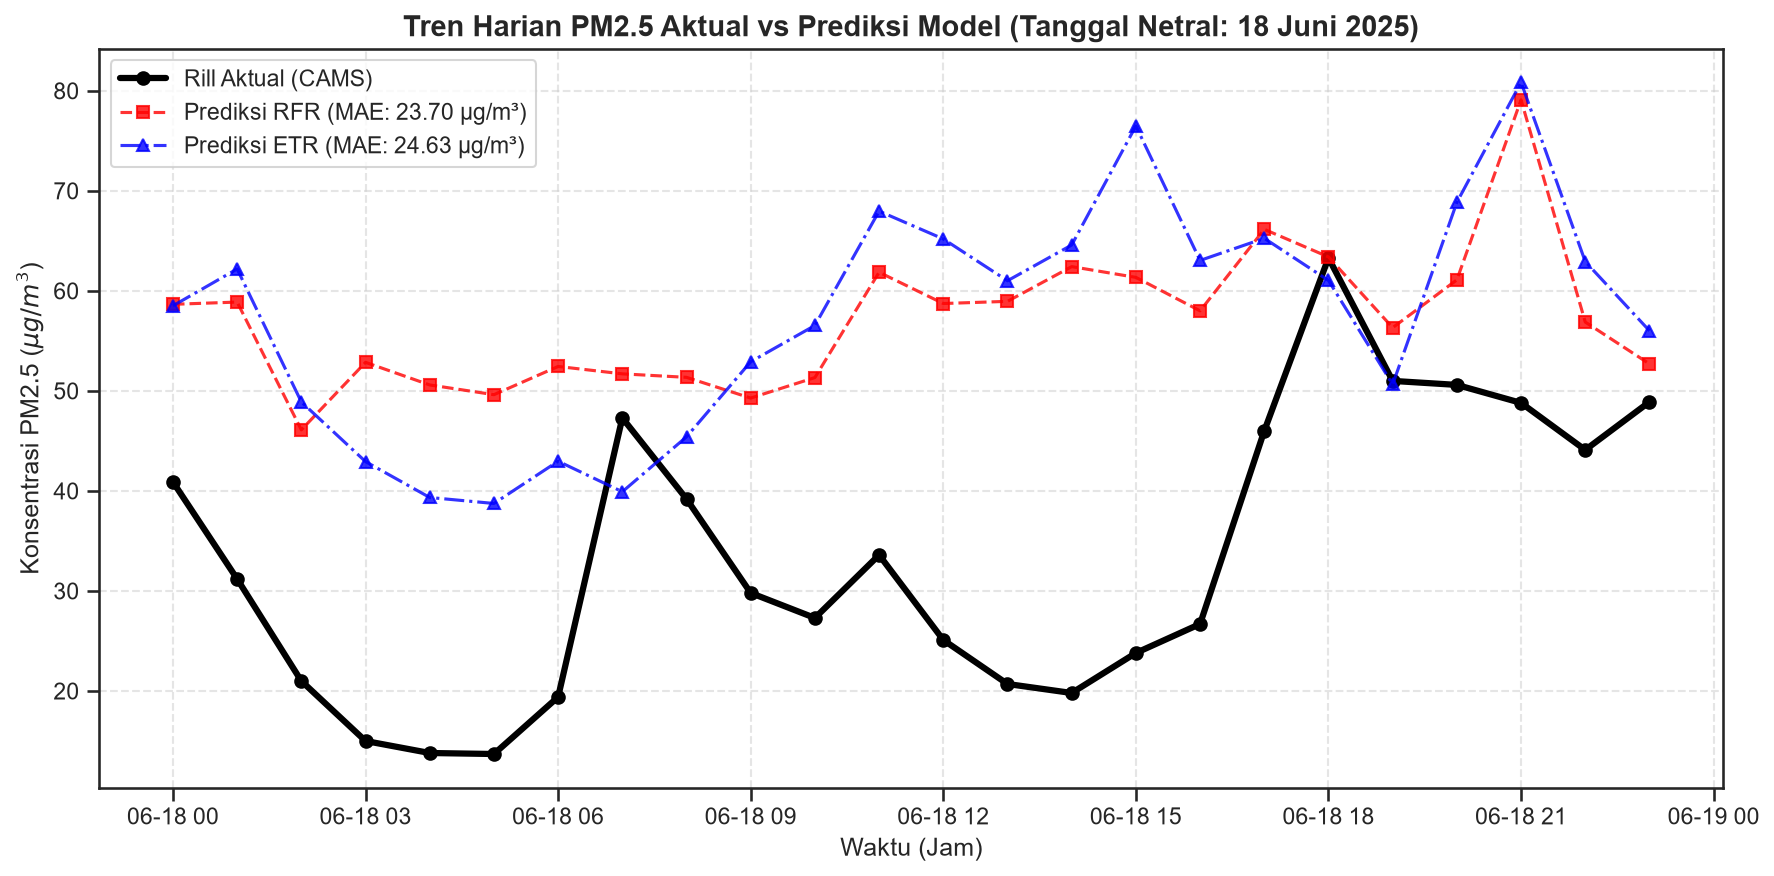

✓ Grafik perbandingan harian berhasil disimpan di: results\images\daily_validation_coords_comparison.png


In [ ]:
# =================================================================
# CELL: VISUALISASI TIME-SERIES DENGAN MAE & RMSE (RFR VS ETR VS RILL)
# =================================================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Pastikan kedua model dengan koordinat sudah ter-fit
# (Dijalankan pada data df_lag_train yang sudah bersih)
X_train = df_lag_train[features_with_coords_lags]
y_train = df_lag_train[target]

# Train RFR
rfr_model = RandomForestRegressor(
    n_estimators=100, max_depth=20, max_features='log2', min_samples_split=2, random_state=42, n_jobs=-1
)
rfr_model.fit(X_train, y_train)

# Train ETR
etr_model = ExtraTreesRegressor(
    n_estimators=200, max_depth=None, max_features=None, min_samples_split=5, random_state=42, n_jobs=-1
)
etr_model.fit(X_train, y_train)

# 2. Siapkan data uji dengan koordinat Kembangan
df_val_plot = df_val_24h.copy()
df_val_plot['latitude'] = val_lat
df_val_plot['longitude'] = val_lon
X_test_plot = df_val_plot[features_with_coords_lags]
y_actual_plot = df_val_plot["pm2_5"].values

# 3. Prediksi PM2.5
y_pred_rfr = rfr_model.predict(X_test_plot)
y_pred_etr = etr_model.predict(X_test_plot)

# 4. Hitung MAE & RMSE Harian secara dinamis
mae_rfr = mean_absolute_error(y_actual_plot, y_pred_rfr)
mae_etr = mean_absolute_error(y_actual_plot, y_pred_etr)
rmse_rfr = np.sqrt(mean_squared_error(y_actual_plot, y_pred_rfr))
rmse_etr = np.sqrt(mean_squared_error(y_actual_plot, y_pred_etr))

print("=================================================================")
print("EVALUASI AKURASI HARIAN (MAE & RMSE):")
print("=================================================================")
print(f"RFR (Dengan Koordinat) -> MAE: {mae_rfr:.2f} µg/m³ | RMSE: {rmse_rfr:.2f} µg/m³")
print(f"ETR (Dengan Koordinat) -> MAE: {mae_etr:.2f} µg/m³ | RMSE: {rmse_etr:.2f} µg/m³")
print("=================================================================")

# 5. Gambar Grafik Line Chart Perbandingan 24 Jam
plt.figure(figsize=(12, 6))

# Plot Rill (Aktual)
plt.plot(
    df_val_plot["time"], y_actual_plot,
    label='Rill Aktual (CAMS)', color='black', linewidth=3, marker='o'
)

# Plot Prediksi RFR (Menampilkan MAE)
plt.plot(
    df_val_plot["time"], y_pred_rfr,
    label=f'Prediksi RFR (MAE: {mae_rfr:.2f} µg/m³)', color='red', linestyle='--', marker='s', alpha=0.8
)

# Plot Prediksi ETR (Menampilkan MAE)
plt.plot(
    df_val_plot["time"], y_pred_etr,
    label=f'Prediksi ETR (MAE: {mae_etr:.2f} µg/m³)', color='blue', linestyle='-.', marker='^', alpha=0.8
)

# Dekorasi Grafik
plt.title('Tren Harian PM2.5 Aktual vs Prediksi Model (Tanggal Netral: 18 Juni 2025)', fontsize=14, fontweight='bold')
plt.xlabel('Waktu (Jam)', fontsize=12)
plt.ylabel(r'Konsentrasi PM2.5 ($\mu g/m^3$)', fontsize=12) # Menggunakan raw string 'r'
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Simpan Grafik
daily_validation_path = os.path.join('results', 'images', 'daily_validation_coords_comparison.png')
os.makedirs(os.path.dirname(daily_validation_path), exist_ok=True)
plt.savefig(daily_validation_path, dpi=300)
plt.show()

print(f"✓ Grafik perbandingan harian berhasil disimpan di: {daily_validation_path}")